# 2. Exploratory Data Analysis (EDA)
Tahap ini bertugas menganalisis pola sebaran data, outlier, korelasi, dan perbandingan antar Program Studi sebelum pemodelan.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Library EDA berhasil di-import!')

Library EDA berhasil di-import!


In [2]:
# Load dataset hasil preprocessing
file_path = None
for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    candidate = p / 'data' / 'processed' / 'student_features_clean.csv'
    if candidate.exists():
        file_path = candidate
        break

if not file_path:
    raise FileNotFoundError('student_features_clean.csv belum ada. Jalankan 01_preprocessing.ipynb terlebih dahulu!')

df = pd.read_csv(file_path)
features = ['wellbeing', 'academic_pressure', 'social_support', 'career_readiness']
print(f'Data terbaca: {df.shape[0]} baris x {df.shape[1]} kolom')
df.head(3)

Data terbaca: 114 baris x 10 kolom


,student_id,gender,semester,prodi,wellbeing,academic_pressure,social_support,career_readiness,keluhan_akademik,kebutuhan_karier
0,MHS-001,Laki-laki,5,Teknik Elektro Industri,66.7,43.8,75.0,53.1,Fasilitas laboratorium yang mungkin harus lebi...,Pelatihan yang akan dibuat bekal di dunia kerja
1,MHS-002,Perempuan,3,Teknologi Multimedia Broadcasting,41.7,53.1,59.4,6.2,"merasa kapasitas otak tidak mumpuni, yang akhi...",mungkin dukungan mental? bingung jugaa
2,MHS-003,Laki-laki,5,Teknik Informatika,61.1,40.6,59.4,43.8,Wifi PENS busuk,Koneksi orang dalam


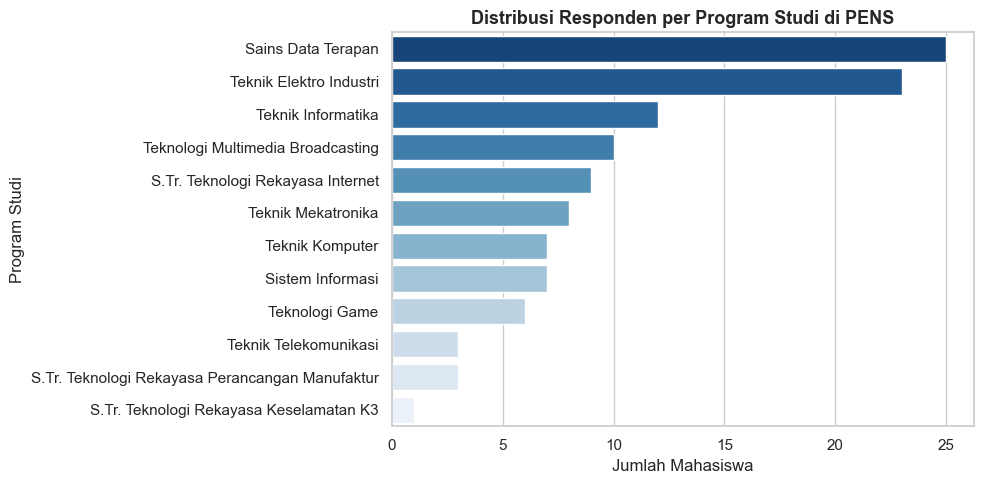

In [3]:
# 1. Distribusi Responden per Program Studi
plt.figure(figsize=(10, 5))
counts = df['prodi'].value_counts()
sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette='Blues_r', legend=False)
plt.title('Distribusi Responden per Program Studi di PENS', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Mahasiswa')
plt.ylabel('Program Studi')
plt.tight_layout()
plt.show()

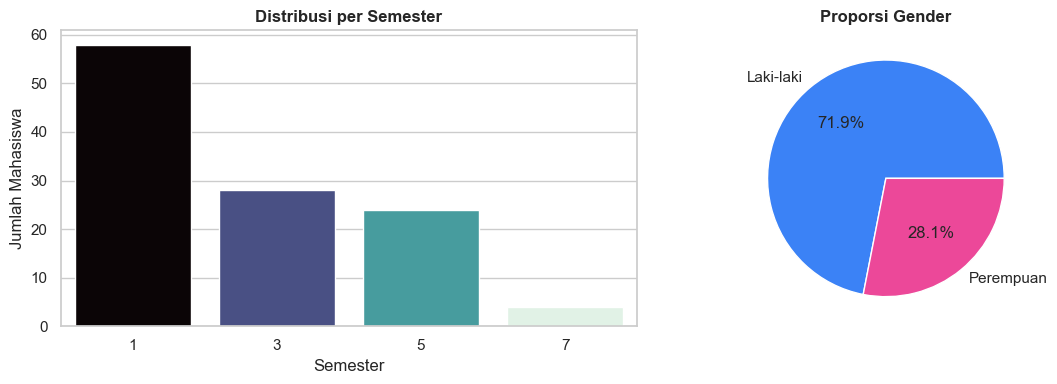

In [4]:
# 2. Distribusi Responden per Semester & Gender
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='semester', hue='semester', palette='mako', ax=axes[0], legend=False)
axes[0].set_title('Distribusi per Semester', fontweight='bold')
axes[0].set_xlabel('Semester')
axes[0].set_ylabel('Jumlah Mahasiswa')

df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1], colors=['#3B82F6', '#EC4899'])
axes[1].set_title('Proporsi Gender', fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [5]:
# 3. Ringkasan Statistik Deskriptif 4 Dimensi
desc = df[features].agg(['count', 'mean', 'std', 'min', 'median', 'max', 'skew']).round(2)
print('=== STATISTIK DESKRIPTIF 4 DIMENSI INDIKATOR ===')
desc

=== STATISTIK DESKRIPTIF 4 DIMENSI INDIKATOR ===


,wellbeing,academic_pressure,social_support,career_readiness
count,114.00,114.00,114.00,114.00
mean,60.31,40.13,73.30,56.47
std,19.11,18.04,18.41,21.12
min,8.30,0.00,18.80,3.10
median,58.30,40.60,75.00,53.10
max,100.00,78.10,100.00,100.00
skew,-0.07,-0.18,-0.58,-0.12


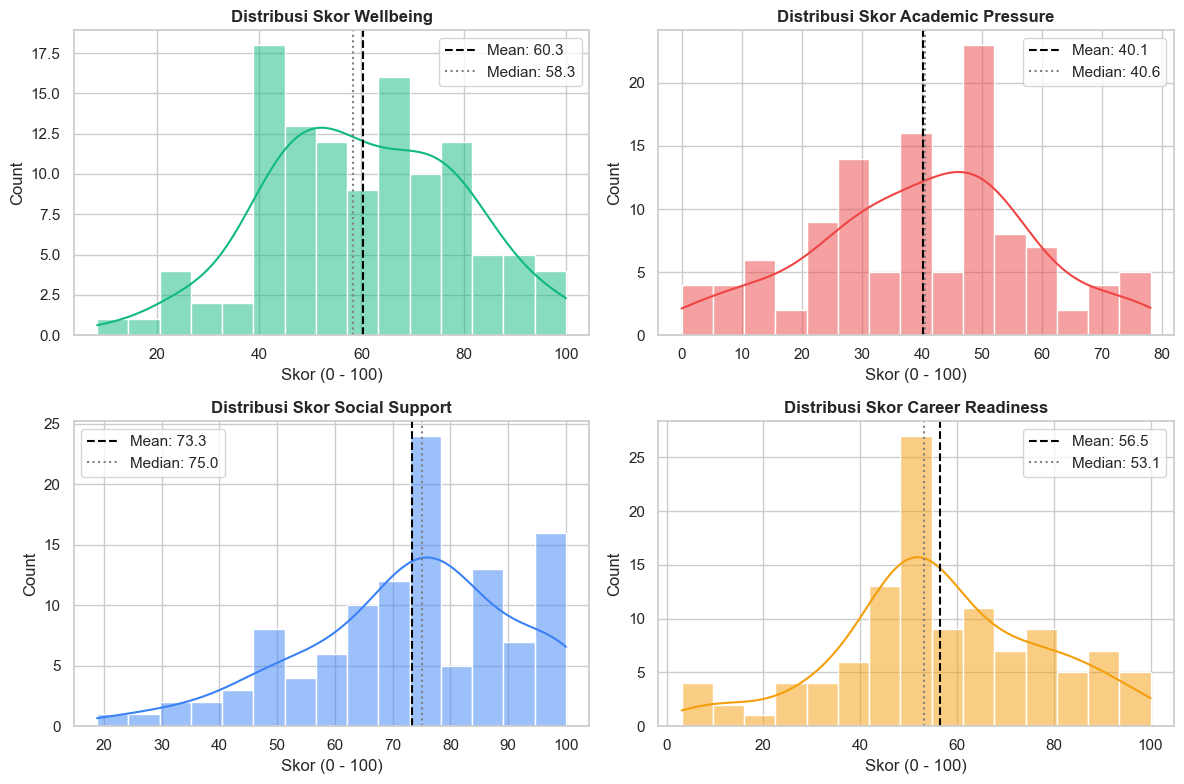

In [6]:
# 4. Distribusi Frekuensi (Histogram & KDE) 4 Dimensi
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['#10B981', '#EF4444', '#3B82F6', '#F59E0B']

for i, col in enumerate(features):
    ax = axes[i // 2, i % 2]
    sns.histplot(df[col], kde=True, ax=ax, color=colors[i], bins=15)
    ax.axvline(df[col].mean(), color='black', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='gray', linestyle=':', label=f'Median: {df[col].median():.1f}')
    ax.set_title(f'Distribusi Skor {col.replace("_", " ").title()}', fontweight='bold')
    ax.set_xlabel('Skor (0 - 100)')
    ax.legend()

plt.tight_layout()
plt.show()

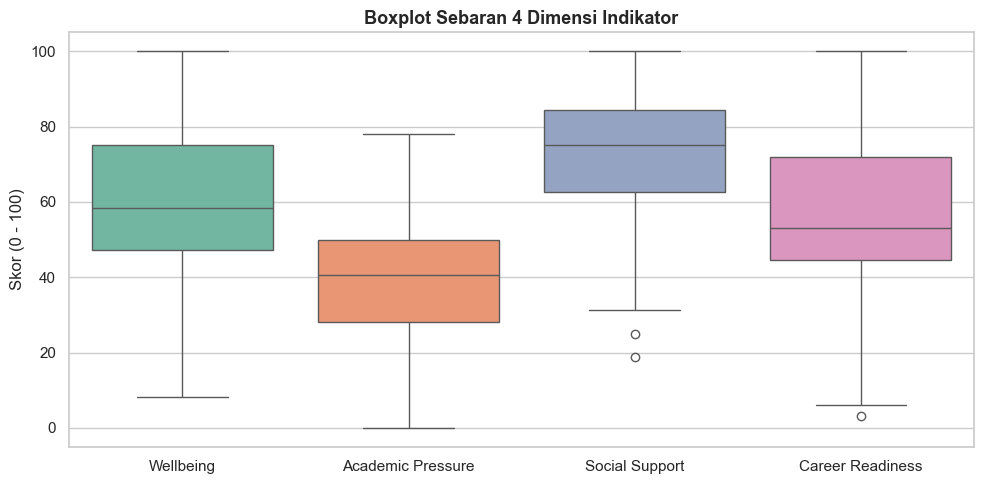

In [7]:
# 5. Boxplot untuk Deteksi Outlier
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[features], palette='Set2')
plt.title('Boxplot Sebaran 4 Dimensi Indikator', fontsize=13, fontweight='bold')
plt.ylabel('Skor (0 - 100)')
plt.xticks(ticks=range(4), labels=[f.replace('_', ' ').title() for f in features])
plt.tight_layout()
plt.show()

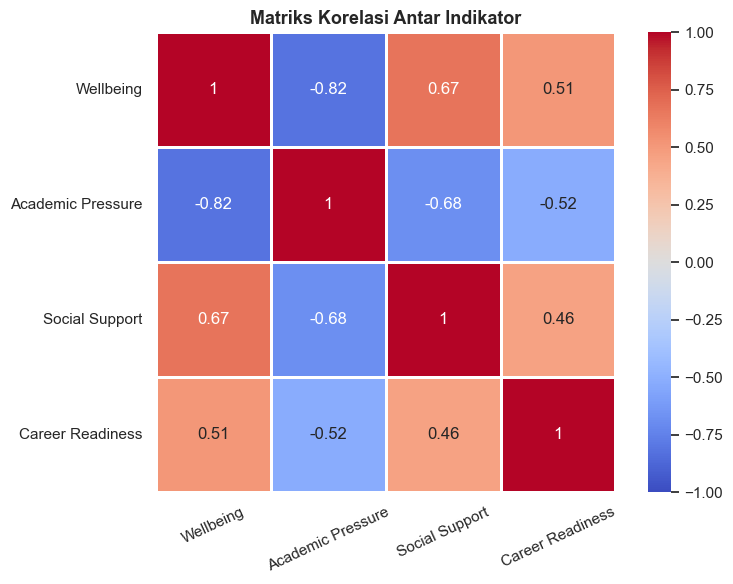

In [8]:
# 6. Matriks Korelasi Pearson antar Indikator (Heatmap)
corr = df[features].corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=1)
plt.title('Matriks Korelasi Antar Indikator', fontsize=13, fontweight='bold')
plt.xticks(ticks=np.arange(4) + 0.5, labels=[f.replace('_', ' ').title() for f in features], rotation=25)
plt.yticks(ticks=np.arange(4) + 0.5, labels=[f.replace('_', ' ').title() for f in features], rotation=0)
plt.tight_layout()
plt.show()

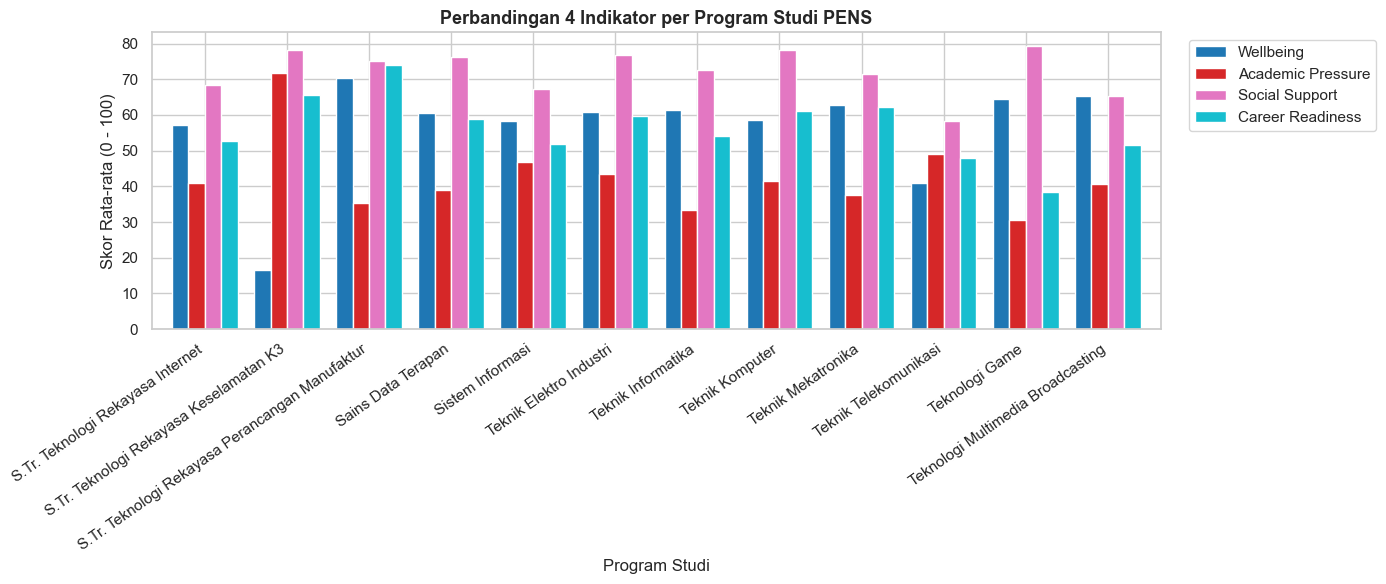

In [9]:
# 7. Perbandingan Skor Rata-rata per Program Studi
prodi_mean = df.groupby('prodi')[features].mean().round(1)

prodi_mean.plot(kind='bar', figsize=(14, 6), colormap='tab10', width=0.8)
plt.title('Perbandingan 4 Indikator per Program Studi PENS', fontsize=13, fontweight='bold')
plt.ylabel('Skor Rata-rata (0 - 100)')
plt.xlabel('Program Studi')
plt.xticks(rotation=35, ha='right')
plt.legend([f.replace('_', ' ').title() for f in features], bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()